# Projet ADEME - Optimisation de la Mobilité Multimodale Intelligente
**Auteur:** Ulysse Bruley | **Structure:** CesiCDP | **Date**: [2026]

## 1. Introduction et Contexte de l'Étude
Face à l'urgence climatique et aux engagements nationaux (division par 4 des émissions d'ici 2050), la transition écologique impose une refonte de nos habitudes. Les pouvoirs publics ne pouvant contraindre chaque acteur individuellement, l'innovation technologique et l'optimisation des processus existants deviennent nos meilleurs leviers d'action.

C'est dans ce cadre que l'ADEME a lancé un appel à manifestation d'intérêt pour de nouvelles solutions de mobilité. Au sein de **CesiCDP**, nous sommes convaincus que la logistique du transport (distribution, collecte, livraison) est un secteur clé. Optimiser les tournées de véhicules ne se résume plus seulement à un gain financier pour les entreprises : c'est une nécessité environnementale pour limiter les émissions de gaz à effet de serre

## 2. Définition du Problème: Au-delà du simple Voyageur de Commerce 
L'objectif principal fixé par l'ADEME est de calculer, sur un réseau routier, une tournée permettant de relier un sous-ensembles de villes puis de revenir au point de départ, en minimisant la durée totale. Dans sa forme la plus pure, il s'agit du célèbre **Problème du Voyageur du Commerce** (TSP - Traveling Salesperson Problem).

Cependant, la réalité du terrain est bien plus complexe. Un livreur ou un service de collecte ne se déplace pas librement. Pour répondre aux éxigences concrètes de la logistique, nous avons intégré deux contraintes majeures à notre étude: 
- **Les fenêtres Temporelles (Time Window):** Les clients ou les infrastructures ne sont pas disponibles 24h/24. Chaque point d'arrêt possède une heure d'ouverture et une heure de fermeture. Le véhicule peut arriver en avance (et devra patienter), mais il ne peut en aucun cas arriver en retard.
- **Les dépendancexs entre visites (Precedence Constraints):** Dans de nombreux scénarions (comme la livraison de matériel spécifique ou le ramassage de colis à redéposer ailleurs), un point *A* doit impérativement être visité avant un point *B*.

Dans la littérature scientifique de la Recherche Opérationnelle, notre problème s'apparente donc au **TSPTW-PC** (Traveling Salesperson Problem with Time Windows and Precedence Constraints).

## 3. Modélisation Formelle du Problème 
Pour résoudre ce problème algorithmiquement, nous devons d'abord le traduire dans le langage des mathématiques.      
Nous modélisons notre réseau routier sous la forme d'un graphe orienté complet: $G = (V,A)$

### 3.1 Les Ensembles et Paramètres (Données d'entrée)
- **Sommets:** L'ensemble $V = \{0,1,\ldots,n,n+1\}$. Le sommet $0$ est le dépôt de départ, l'ensemble $\{1,\ldots,n\}$ représente les villes à visiter.
- **Arcs:** L'ensemble $A = \{(i,j) \in V \times V \mid i \neq j\}$ représente les routes possibles.
- **Temps de Trajet:** $t_{ij}$ représente le temps de trajet pour aller du sommer $i$ au sommet $j$.
- **Fenêtres de temps:** Chaque sommet $i$ est associé à une fenêtre $[e_i,l_i]$, où $e_i$ est l'heure de début au plus tôt et $l_i$ l'heure de fin au plus tard. On note $s_i$ le temps de service (chargement/déchargement) au sommer $i$.
- Précédences: $P$ est l'ensemble des paires $(i,j)$ signifiant que $i$ doit être visité avant $j$.

### 3.2 Les Variables de Décisions (Ce que l'on va chercher)
Notre modèle de modélisation repose sur deux types de décisions interdépendantes: 
1. **Le Routage:** Une variable binaire $x_{i,j} \in {0,1}$ qui vaut $1$ si le véhicule emprunte la route allant de $i$ à $j$, et $0$ sinon.
2. **La Planification (Scheduling):** Une variable continue $T_i \geq 0$ qui enregistre l'heure de début de service au sommet $i$.

### 3.3 La Fonction Objectif 
Nous souhaitons minimiser le temps de trajer totale de la tournée. On peut l'exprimer comme la minimisation de la somme des temps de parcours (et de service si applicable) :
$$\text{Minimiser } Z = \sum_{i \in V} \sum_{j \in V} t_{ij} x_{ij}$$

### 3.4 Les Contraintes du Système
Pour que la tournée soit valide, notre modèle doit réspecter les règles suivantes: 


1. **Continuité du parcours (conservation du flux):**    
   Chaque ville doit être visitée une et une seule fois. Tout véhicule qui entre dans une ville doit en ressortir.
   - Pour la sortie : Pour toute ville $i$, il existe une unique destination $j$ telle que la route est empruntée.
$$\forall i \in V, \quad \exists! j \in V \setminus \{i\} \mid x_{ij} = 1$$
- Pour l'entrée : Pour toute ville $j$, il existe une unique provenance $i$ telle que la route est empruntée.
$$\forall j \in V, \quad \exists! i \in V \setminus \{j\} \mid x_{ij} = 1$$

    
1. **Cohérence du temps et élimination des sous tours:**    
   L'heure d'arrivée à une ville $j$ dépend de l'eheure de départ de la ville précédente $i$. Nous utilisons une grande constante $M$ (technique du $\text{"Big-M"}$) pour lier le routage $(x_{i,j})$ au temps $(T_i)$. Si $x_{i,j} = 1$, le temps s'incrémente normalement.
   $$T_i + s_i + t_{ij} - M(1 - x_{ij}) \leq T_j \forall(i,j) \in A$$

2. **Respect des fenêtres temporelles:**    
   Le service ne peut commencer qu'après l'ouverture de $e_i$ et avant la fermeture de $l_i$.
   $$e_i \leq T_i \leq l_i \forall i \in V$$

3. **Respect des contraintes de précédence:**
   Si $i$ doit être visité avant $j$, le dévut de serviceen $j$ doit avoir lieu après la fin du service en $i$ plus le temps de trajet minimal entre les deux.
   $$T_i + s_i +t_{i \to j} \leq T_j \forall (i,j) \in P$$


## 4. Problème d'optimisation et problème de décision associé

Avant d'analyser la complexité de notre problème (le TSPTW-PC), on doit le formuler sous ses deux angles: 
- L'optimisation (ce que l'on veut résoudre).
- La décision (la question qui servira à la preuve de la complexité de celui-ci).

### Le problème d'optimisation (TSPTW-PC): 
- **Données** : Un graphe complet orienté $G=(V,A)$, une matrice des temps de trajet $t_{ij}$, des fenêtres temporelles $[e_i, l_i]$ et temps de service $s_i$ pour chaque sommet, et un ensemble $P$ de contraintes de précédence.
- **Question** : Quelle est la valeur minimale du temps total de parcours pour relier toutes les villes en respectant l'ensemble des contraintes de fenêtres temporelles et de précédence ?

### Le Problème de Décision Associé :
- **Données** : Les mêmes données que le problème d'optimisation, plus une valeur cible (un budget temps) notée $k$.
- **Question** : Existe-t-il une tournée visitant tous les sommets une et une seule fois, respectant les fenêtres de temps et les précédences, et dont la durée totale est inférieure ou égale à $k$ ?

## 5. Preuve de la NP-Complétude du TSPTW-PC
Pour justifier nos futurs choix algorithmiques, nous devons démontrer que notre problème est au moins aussi difficile que les problèmes les plus durs de la classe NP (NP-Complet). La démonstration se fait en deux étapes.

### Étape 1 : Montrer que le problème est dans la classe NP
Il faut prouver qu'il est possible de vérifier la validité d'une solution proposée en un temps polynomial. Notre algorithme de vérification doit: 
1. Vérifier que la liste forme un circuit complet passant par toutes les villes une seule fois (Complexité $\mathcal{O}(n)$).
2. Vérifier pour chaque ville $i$ que l'heure de passage est bien comprise dans $[e_i, l_i]$ (Complexité $\mathcal{O}(n)$).
3. Vérifier que pour chaque paire $(i, j)$ dans $P$, la ville $i$ apparaît bien avant $j$ dans la chronologie (Complexité $\mathcal{O}(n^2)$ au pire).
4. Faire la somme des temps de trajet et vérifier que le total est $\le k$ (Complexité $\mathcal{O}(n)$).

Toutes ces vérifications se font via de simples boucles. La vérification totale s'exécute donc en un temps polynomial $\mathcal{O}(n^2)$. Le problème TSPTW-PC appartient bien à NP.

### Étape 2 : Réduction polynomiale depuis le TSP  
Nous savons déjà que le problème du Voyageur de Commerce (TSP classique) est **NP-Complet**. Nous allons montrer que le TSP se réduit polynomialement à notre problème (TSPTW-PC).

#### La traduction: 
Prenons n'importe quelle instance du TSP (un graphe $G^{\prime}$ et un budget $k$). Nous la transformons en une instance de notre problème TSPTW-PC de la manière suivante :
- On garde le même graphe $G^{\prime}$, les mêmes sommets et les mêmes coûts de trajet.
- On définit l'ensemble des précédences $P$ comme étant vide ($P = \emptyset$)
- On "désactive" les fenêtres de temps en donnant à chaque ville une ouverture à $0$ et une fermeture à l'infini : $[0, \infty]$.
Cette transformation triviale s'effectue en temps **polynomial** $\mathcal{O}(n)$.

#### La conservation de la réponse 
- **Si la réponse au TSP est "oui":** Il existe une tournée de coût $\le k$. Dans notre nouvelle instance TSPTW-PC, le véhicule suit exactement la même route. Puisque toutes les fenêtres de temps sont infinies et qu'il n'y a aucune contrainte de précédence, la route est parfaitement valide et son coût reste $\le k$. La réponse est "**Oui**".
- **Si la réponse au TSPTW-PC est "oui":** Il existe une tournée de coût $\le k$ respectant des fenêtres infinies et aucune précédence. Cette tournée passe une seule fois par chaque sommet pour un coût $\le k$. C'est par donc par définition une solution valide pour le TSP d'origine. La réponse "**Non**" est donc également conservée s'il n'y a pas de solution.

### Conclusion sur la complexité: 
Puisque le problème **TSP** se réduit polynomialement au **TSPTW-PC**, notre problème est **NP-difficile**. Comme il a été démontré à *l'étape 1* qu'il est également dans **NP**, nous concluons que le **TSPTW-PC** est **NP-Complet**. 

## 6. Conclusion et perspectives de résolutions 
La modélisation formelle et la preuve de complexité mettent en lumière un fait fondamental : pour répondre à l'appel d'offres de l'ADEME sur des instances réalistes (plusieurs dizaines ou centaines de villes), les méthodes de résolution exactes (comme la Programmation Linéaire) exploseront en temps de calcul.

Pour produire le code en Python attendu dans le second livrable, nous devrons impérativement nous tourner vers des méthodes de résolution approchées (**heuristiques ou méta-heuristiques**). Celles-ci sacrifieront la garantie de trouver la solution optimale (solution parfaite), au profit de l'obtention d'une excellente solution en un temps d'exécution acceptable pour les acteurs de la logistique.

## 4. Analyse de la Complexité Théorique
La modélisation étant posée, il est crucial d'évaluer la difficulté inhérente à ce problème avant de choisir nos méthodes de résolution. 

Le problème du *Voyageur de Commerce* (TSP) classique est l'un des problèmes fondamentaux de l'optimisation combinatoire. Il est prouvé comme étant **NP-difficile** (Karp, 1972). Cela signifie qu'a ce jour il n'éxiste aucun algorithme capable de trouver la solution optimale en un temps polynomial pour toutes les instances du problème. Le temps de calcul croît de manière exponentielle avec l'ajout de nouvelles villes.

L'ajout de nos deux contraintes (fenêtres de temps et précédences) augmente cette complexité! 
1. **Recherche de faisabilité:** Dans un *TSP* classique, trouver une tournée valide (même très mauvaise) est triviale. Dans notre problème (*TSPTW*), le simple fait de trouver une tournée qui respecte toutes les fenêtres de temps et en soit un problème **NP-complet** (Savelsberg, 1985).
2. **Contraintes de précédence:** Elles restreignent l'espace de recherche (ce qui peut dans certains cas aider les algorithmes exacts à couper des branches d'exploration), mais elles maintiennent la complexité globale du problème dans la classe **NP-difficiles**.

**Conclusion sur la complexité:**
Notre problème est fortement **NP-difficile**. Par conséquent, pour des instances de grande tailles (dans notre cas de nombreuses villes), les méthodes exactes de résolition (comme la programmation linéaire en nombre entiers) risquent de na pas aboutir dans un temps raisonnable. C'est pourquoi, dans les prochaines étapes du projer, nous devrons explorer des approches *heuristiques* ou *méta-heuristiques* capavles de fournir de très bonnes solutions en un temps de calcul acceptable pour l'ADEME.


## 5. Références Bibliographiques 
- Karp, R. M. (1972). Reducibility among combinatorial problems. Complexity of computer computations.

- Savelsbergh, M. W. (1985). Local search in routing problems with time windows. Annals of Operations Research.

- Problème du voyageur de commerce (https://fr.wikipedia.org/wiki/Probl%C3%A8me_du_voyageur_de_commerce)

- Problème NP-complet (https://fr.wikipedia.org/wiki/Probl%C3%A8me_NP-complet)

# Projet ADEME - Implémentation et Résolution Algorithmique
Auteur : Bruley Ulysse | Structure : CesiCDP | Date : 13/04/2026

## 1. Introduction: De la théorie à la pratique
Dans notre livrable précédent, nous avons modélisé mathématiquement le problème d'optimisation et de tournées de véhicules avec fenêtres temporelles et contraintes de précédence (**TSPTW-PC**). Nous avons par ailleurs démontré que ce problème est **NP-Complet**.

Cette conclusion théorique a un impact direct sur notre stratégie de résolution : face à des instances de grande taille, chercher la solution parfaite avec une méthode exacte prendrait un temps de calcul inacceptable pour les acteurs de la logistique.

L'objectif de ce second livrable est de concevoir, implémenter et comparer trois méthodes de résolution différentes :
- Une heuristique constructive (**Algorithme Glouton**) : Pour obtenir une solution initiale valide extrêmement rapidement.
- Une méta-heuristique (**Recuit Simulé**) : Pour optimiser intelligemment la solution initiale en explorant l'espace de recherche.
- Un solveur industriel (**Google OR-Tools**) : Pour benchmarker nos algorithmes maison face à l'état de l'art mondial utilisé par les géants de la tech.

Avant de lancer nos algorithmes, nous devons d'abord construire un générateur d'instances capable de simuler des réseaux routiers de manière réaliste.

## 2. Génération des instances de test 
Pour évaluer la robustesse de nos algorithmes, nous ne pouvons pas nous contenter d'un seul jeu de données. Nous avons développé un générateur d'instances aléatoires en Python.

### Paramètres choisis: 
- **Graphe complet:** Nous supposons que chaque ville est théoriquement accessible depuis n'importe quelle autre (fermeture métrique du graphe). Les distances/temps sont calculés via la distance Euclidienne.
- **Fenêtres Temporelles (Time Windows):** Générées de manière à laisser une marge de manœuvre, avec un temps de service fixe pour simuler le déchargement.
- **Précédences:** Ajout de contraintes strictes (A doit être visité avant B) de manière aléatoire mais cohérente (sans créer de boucles impossibles).



In [92]:
import numpy as np
import random
import math
import matplotlib.pyplot as plt

class InstanceTSPTW:
    def __init__(self, n_villes, max_coord=100, num_precedences=2):
        self.n_villes = n_villes
        # Sommet 0 = Dépôt, Sommets 1 à n = Villes
        self.coords = {i: (random.randint(0, max_coord), random.randint(0, max_coord)) for i in range(n_villes + 1)}
        
        # Matrice des temps/distances (Euclidienne)
        self.matrice_temps = np.zeros((n_villes + 1, n_villes + 1))
        for i in range(n_villes + 1):
            for j in range(n_villes + 1):
                if i != j:
                    dist = math.hypot(self.coords[i][0] - self.coords[j][0], self.coords[i][1] - self.coords[j][1])
                    self.matrice_temps[i][j] = round(dist, 2)
                    
        # Fenêtres de temps [e_i, l_i] et temps de service s_i
        self.time_windows = {0: (0, 10000)} # Le dépôt est toujours ouvert
        self.service_times = {0: 0}
        
        for i in range(1, n_villes + 1):
            e_i = random.randint(300, 480)
            l_i = e_i + random.randint(480, 600) # Fenêtre plus ou moins large
            self.time_windows[i] = (e_i, l_i)
            self.service_times[i] = random.randint(5, 15) # Temps de déchargement ou temps de service
            
        # Génération de précédences cohérentes en évitant de faire des boucles ou des contradictions (pas de B avant A si A doit être avant B)
        self.precedences = []
        villes_dispo = list(range(1, n_villes + 1))
        random.shuffle(villes_dispo)
        for _ in range(min(num_precedences, len(villes_dispo)//2)):
            i = villes_dispo.pop()
            j = villes_dispo.pop()
            # On s'assure que la fenêtre de j ne ferme pas avant l'ouverture de i
            if self.time_windows[i][0] + self.service_times[i] + self.matrice_temps[i][j] <= self.time_windows[j][1]:
                self.precedences.append((i, j))

# Création d'une instance de test de 10 villes
test_instance = InstanceTSPTW(n_villes=10, num_precedences=2)
print(f"Génération réussie : 1 dépôt, {test_instance.n_villes} villes.")
print(f"Contraintes de précédences générées : {test_instance.precedences}")

Génération réussie : 1 dépôt, 10 villes.
Contraintes de précédences générées : [(9, 7), (3, 5)]


## 3. Méthode 1 : L'Heuristique Constructive (Algorithme Glouton)

Maintenant que nos données sont prêtes, nous implémentons notre première méthode de résolution. L'algorithme glouton (ou du "Plus Proche Voisin" adapté) ne garantit pas la solution optimale, mais il garantit la rapidité.

### Principe: 
À chaque étape, le véhicule, situé sur une ville actuelle, évalue toutes les villes non encore visitées. Il exclut celles dont les contraintes de précédence ne sont pas remplies ou dont la fenêtre de temps est déjà fermée. Parmi les villes restantes, il se dirige vers celle qui minimise le temps d'attente et de trajet cumulé.

In [93]:
def resoudre_glouton(instance): 
    """
    Algorithme constructif pour trouver une solution initiale.
    Doit réspecter les contraintes de temps et de précédences.
    """
        
    tournee = [0]  # On part du dépôt 
    temps_actuel = instance.time_windows[0][0]  # Temps initial = ouverture du dépôt (0)
    villes_non_visitees = set(range(1, instance.n_villes + 1))
    
    # Dictionnaire pour tracker les temps de début de service à chaque ville
    temps_service = {0: temps_actuel}
    
    while villes_non_visitees:
        ville_courante = tournee[-1]
        
        # ========== ÉTAPE 1: Filtrer les villes respectant les précédences ==========
        villes_precedences_ok = []
        
        for ville_candidate in villes_non_visitees:
            # Vérifier si tous les prédécesseurs de cette ville ont été visitées
            predecesseurs_respectes = True
            
            for (pred, succ) in instance.precedences:
                # Si cette ville est un successeur (succ == ville_candidate)
                if succ == ville_candidate:
                    # Le prédécesseur (pred) doit avoir été visité
                    if pred in villes_non_visitees:  # pas encore visité
                        predecesseurs_respectes = False
                        break
            
            if predecesseurs_respectes:
                villes_precedences_ok.append(ville_candidate)
        
        # ========== ÉTAPE 2: ==========

        # Toutes les villes respectant les précédences sont candidates
        villes_candidates = villes_precedences_ok

        if not villes_candidates:
            print("❌ Bloqué par les précédences")
            return None, float('inf'), {}

        # ========== ÉTAPE 4: Choisir la meilleure ville selon le critère glouton ==========
        # Critère intelligent: minimiser (temps_trajet + attente estimée)
        for ville_candidate in villes_candidates:
            temps_trajet = instance.matrice_temps[ville_courante][ville_candidate]
            temps_arrivee = temps_actuel + instance.service_times[ville_courante] + temps_trajet
            
            e_i, l_i = instance.time_windows[ville_candidate]

            DUREE_JOUR = 1440
            heure_jour = temps_arrivee % DUREE_JOUR

            if heure_jour <= l_i:
                temps_debut_service = temps_arrivee + max(0, e_i - heure_jour)
            else:
                attente = (DUREE_JOUR - heure_jour) + e_i
                temps_debut_service = temps_arrivee + attente

            score = temps_debut_service
            meilleur_score = float('inf')
            if score < meilleur_score:
                meilleur_score = score
                meilleure_ville = ville_candidate
                meilleur_temps_debut = temps_debut_service
                meilleur_arrivee = temps_arrivee
                        

        # ========== ÉTAPE 5: Mettre à jour l'état ==========
        # Ajouter la ville à la tournée
        tournee.append(meilleure_ville)
        villes_non_visitees.remove(meilleure_ville)

        temps_actuel = meilleur_temps_debut
        temps_service[meilleure_ville] = meilleur_temps_debut

        print(f"✓ Ville {meilleure_ville} ajoutée | Temps service: {meilleur_temps_debut:.2f}")
    
    # ========== RETOUR AU DÉPÔT ==========
    ville_courante = tournee[-1]
    temps_trajet_retour = instance.matrice_temps[ville_courante][0]
    temps_total = temps_actuel + instance.service_times[ville_courante] + temps_trajet_retour
    
    tournee.append(0)  # Retour au dépôt
    temps_service[0] = temps_total  # Enregistrer le temps de retour au dépôt
    
    print(f"\n{'='*60}")
    print(f"Tournée complète: {tournee}")
    print(f"Temps total: {temps_total:.2f}")
    print(f"{'='*60}\n")
    
    return tournee, temps_total, temps_service, 

In [94]:
def calculer_cout_tournee(tournee, instance):
    """
    Calcule le coût total d'une tournée donnée.
    Vérifie la validité par rapport aux contraintes (time windows avec modulo jour, précédences).
    """
    if tournee is None or len(tournee) < 2:
        return float('inf')

    DUREE_JOUR = 1440
    cout_total = 0
    temps_actuel = instance.time_windows[0][0]  # Cohérent avec le glouton
    temps_service = {0: temps_actuel}

    for i in range(len(tournee) - 1):
        ville_actuelle = tournee[i]
        ville_suivante = tournee[i + 1]

        temps_trajet = instance.matrice_temps[ville_actuelle][ville_suivante]
        cout_total += temps_trajet

        temps_arrivee = temps_actuel + instance.service_times[ville_actuelle] + temps_trajet
        e_j, l_j = instance.time_windows[ville_suivante]

        # Calcul du début de service avec modulo jour (cohérent avec le glouton)
        heure_jour = temps_arrivee % DUREE_JOUR
        if heure_jour <= l_j:
            temps_debut_service = temps_arrivee + max(0, e_j - heure_jour)
        else:
            # On arrive après la fermeture : on attend le lendemain
            attente = (DUREE_JOUR - heure_jour) + e_j
            temps_debut_service = temps_arrivee + attente

        # Vérification : on n'arrive jamais avant la fermeture de la fenêtre (heure locale)
        heure_jour_debut = temps_debut_service % DUREE_JOUR
        if heure_jour_debut > l_j:
            print(f"❌ Violation time window: ville {ville_suivante} — "
                  f"début service à {heure_jour_debut:.2f} (heure locale), fermeture à {l_j}")
            return float('inf')

        temps_service[ville_suivante] = temps_debut_service
        temps_actuel = temps_debut_service

    # Vérification des précédences
    for (pred, succ) in instance.precedences:
        t_pred = temps_service.get(pred)
        t_succ = temps_service.get(succ)
        if t_pred is None or t_succ is None:
            print(f"❌ Ville manquante dans temps_service pour précédence ({pred} → {succ})")
            return float('inf')
        if t_pred + instance.service_times[pred] > t_succ:
            print(f"❌ Violation précédence: ville {pred} (fin à {t_pred + instance.service_times[pred]:.2f}) "
                  f"doit précéder ville {succ} (début à {t_succ:.2f})")
            return float('inf')

    return cout_total


def visualiser_solution(tournee, instance, titre="Solution TSPTW-PC"):
    """
    Visualise la tournée sur un graphe 2D avec les fenêtres de temps et précédences.
    """
    if tournee is None:
        print("Impossible de visualiser : pas de solution.")
        return

    DUREE_JOUR = 1440
    temps_actuel = instance.time_windows[0][0]
    temps_service = {0: temps_actuel}

    # Recalculer les temps de service pour l'affichage
    for i in range(len(tournee) - 1):
        ville_actuelle = tournee[i]
        ville_suivante = tournee[i + 1]

        temps_arrivee = temps_actuel + instance.service_times[ville_actuelle] + instance.matrice_temps[ville_actuelle][ville_suivante]
        e_j, l_j = instance.time_windows[ville_suivante]

        heure_jour = temps_arrivee % DUREE_JOUR
        if heure_jour <= l_j:
            temps_debut_service = temps_arrivee + max(0, e_j - heure_jour)
        else:
            temps_debut_service = temps_arrivee + (DUREE_JOUR - heure_jour) + e_j

        temps_service[ville_suivante] = temps_debut_service
        temps_actuel = temps_debut_service

    fig, ax = plt.subplots(figsize=(11, 8))

    # ── Précédences en pointillé rouge ──────────────────────────────────────
    for (pred, succ) in instance.precedences:
        x_pred, y_pred = instance.coords[pred]
        x_succ, y_succ = instance.coords[succ]
        ax.annotate(
            "", xy=(x_succ, y_succ), xytext=(x_pred, y_pred),
            arrowprops=dict(arrowstyle="->", color="red", lw=1.2,
                            linestyle="dashed", alpha=0.6)
        )

    # ── Tournée ─────────────────────────────────────────────────────────────
    coords_x = [instance.coords[v][0] for v in tournee]
    coords_y = [instance.coords[v][1] for v in tournee]
    ax.plot(coords_x, coords_y, 'b-', linewidth=2, alpha=0.7, label='Tournée', zorder=3)

    # ── Nœuds ───────────────────────────────────────────────────────────────
    villes_intermediaires = [v for v in tournee if v != 0]
    xs = [instance.coords[v][0] for v in villes_intermediaires]
    ys = [instance.coords[v][1] for v in villes_intermediaires]
    ax.scatter(xs, ys, c='steelblue', s=120, zorder=5)

    # Dépôt
    x0, y0 = instance.coords[0]
    ax.scatter([x0], [y0], c='limegreen', s=350, marker='*', zorder=6, label='Dépôt')

    # ── Labels avec fenêtre de temps et heure de passage ────────────────────
    villes_affichees = set()
    for v in tournee:
        if v in villes_affichees:
            continue
        villes_affichees.add(v)

        x, y = instance.coords[v]
        t = temps_service.get(v, 0)
        heure_locale = t % DUREE_JOUR

        if v == 0:
            label_txt = "D"
        else:
            e_v, l_v = instance.time_windows[v]
            label_txt = f"{v}\n[{e_v}–{l_v}]\n@{heure_locale:.0f}"

        ax.annotate(
            label_txt, (x, y),
            xytext=(6, 6), textcoords='offset points',
            fontsize=7.5, color='black',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6, ec='none')
        )

    # ── Ordre de visite sur les arêtes ──────────────────────────────────────
    for idx in range(len(tournee) - 1):
        v1, v2 = tournee[idx], tournee[idx + 1]
        mx = (instance.coords[v1][0] + instance.coords[v2][0]) / 2
        my = (instance.coords[v1][1] + instance.coords[v2][1]) / 2
        ax.text(mx, my, str(idx + 1), fontsize=7, color='navy',
                ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.15', fc='lightyellow', alpha=0.8, ec='none'))

    # ── Légende précédences ─────────────────────────────────────────────────
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='blue', lw=2, alpha=0.7, label='Tournée'),
        Line2D([0], [0], color='red', lw=1.2, linestyle='--', alpha=0.6, label='Précédence'),
        plt.scatter([], [], c='limegreen', s=200, marker='*', label='Dépôt'),
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=9)

    ax.set_xlabel('Coordonnée X')
    ax.set_ylabel('Coordonnée Y')
    ax.set_title(titre, fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

RÉSOLUTION GLOUTON DU PROBLÈME TSPTW-PC

Instance générée:
  - Nombre de villes: 10
  - Précédences: [(9, 7), (3, 5)]

✓ Ville 29 ajoutée | Temps service: 465.00
✓ Ville 24 ajoutée | Temps service: 506.23
✓ Ville 23 ajoutée | Temps service: 562.42
✓ Ville 22 ajoutée | Temps service: 608.06
✓ Ville 20 ajoutée | Temps service: 665.48
✓ Ville 19 ajoutée | Temps service: 718.53
✓ Ville 25 ajoutée | Temps service: 745.56
✓ Ville 17 ajoutée | Temps service: 788.34
✓ Ville 16 ajoutée | Temps service: 839.14
✓ Ville 21 ajoutée | Temps service: 914.02
✓ Ville 14 ajoutée | Temps service: 1802.00
✓ Ville 13 ajoutée | Temps service: 1879.55
✓ Ville 28 ajoutée | Temps service: 1905.58
✓ Ville 12 ajoutée | Temps service: 1988.97
✓ Ville 26 ajoutée | Temps service: 2072.44
✓ Ville 11 ajoutée | Temps service: 2148.47
✓ Ville 10 ajoutée | Temps service: 2168.03
✓ Ville 18 ajoutée | Temps service: 2234.04
✓ Ville 9 ajoutée | Temps service: 2283.78
✓ Ville 30 ajoutée | Temps service: 3253.00
✓ Ville 7 aj

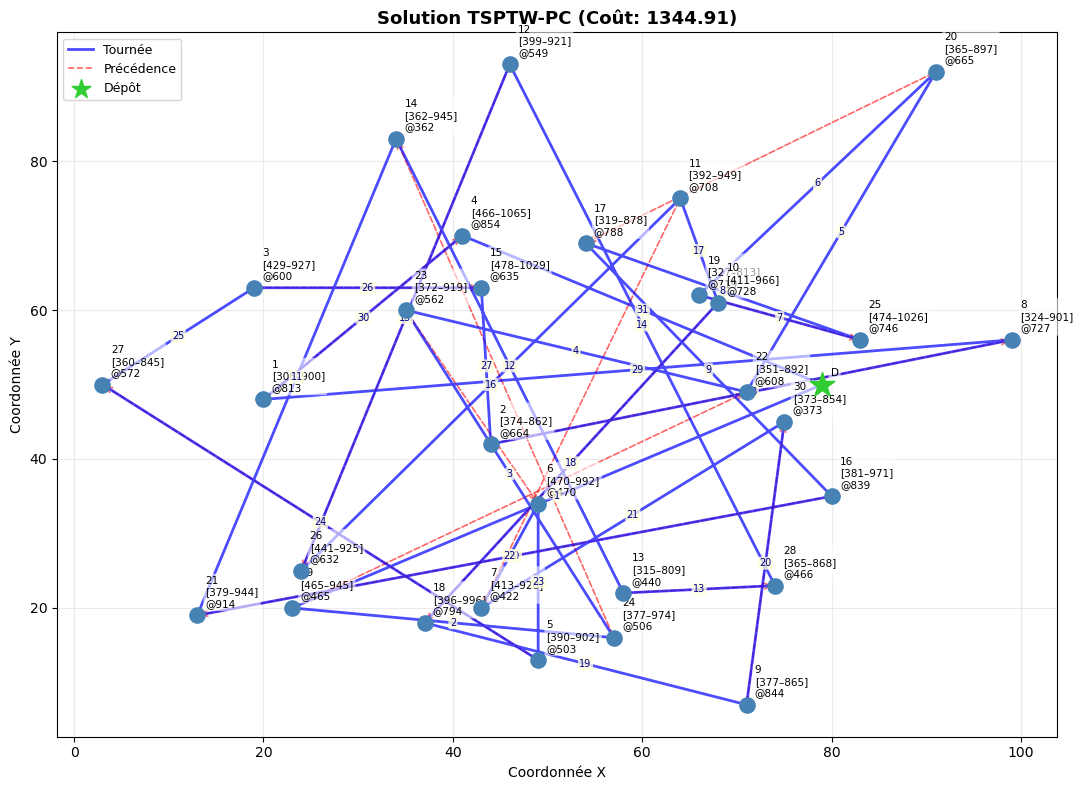

In [95]:

# ============================================================================
# TESTS
# ============================================================================
 
if __name__ == "__main__":
    print("=" * 60)
    print("RÉSOLUTION GLOUTON DU PROBLÈME TSPTW-PC")
    print("=" * 60 + "\n")
    
    # Créer une instance de test
    instance = InstanceTSPTW(n_villes=30, num_precedences=30)
    
    print(f"Instance générée:")
    print(f"  - Nombre de villes: {test_instance.n_villes}")
    print(f"  - Précédences: {test_instance.precedences}\n")
    
    # Résoudre avec l'algorithme glouton
    tournee_gloutonne, temps_glouton, temps_service = resoudre_glouton(instance)
    
    if tournee_gloutonne is not None:
        # Vérifier la validité
        cout = calculer_cout_tournee(tournee_gloutonne, instance)
        
        if cout != float('inf'):
            print(f"✅ Solution valide trouvée!")
            print(f"   Coût total: {cout:.2f}\n")
            
            # Visualiser
            visualiser_solution(tournee_gloutonne, instance, 
                              f"Solution TSPTW-PC (Coût: {cout:.2f})")
        else:
            print(f"❌ Solution invalide détectée")
    else:
        print(f"❌ Impossible de trouver une solution")

In [96]:
import matplotlib.pyplot as plt

def tracer_tournee(instance, tournee, titre="Visualisation de la tournée"):
    """
    Trace le graphe de l'instance et la tournée empruntée en vert.
    """
    plt.figure(figsize=(10, 7))
    
    # 1. Tracer le "bruit de fond" (toutes les routes possibles en gris très clair)
    for i in range(instance.n_villes + 1):
        for j in range(instance.n_villes + 1):
            if i != j:
                xi, yi = instance.coords[i]
                xj, yj = instance.coords[j]
                plt.plot([xi, xj], [yi, yj], color='gray', linestyle='--', linewidth=0.5, alpha=0.2)

    # 2. Tracer la tournée choisie en vert avec des flèches de direction
    for k in range(len(tournee) - 1):
        i = tournee[k]
        j = tournee[k+1]
        xi, yi = instance.coords[i]
        xj, yj = instance.coords[j]
        
        # On dessine une flèche verte du point i au point j
        plt.annotate('', xy=(xj, yj), xytext=(xi, yi),
                     arrowprops=dict(edgecolor='green', facecolor='green', arrowstyle='-|>', lw=2.5))

    # 3. Placer et nommer les sommets
    for i in range(instance.n_villes + 1):
        x, y = instance.coords[i]
        if i == 0:
            # Le Dépôt
            plt.plot(x, y, 'rs', markersize=12, label='Dépôt') # rs = Red Square
            plt.text(x, y + 3, 'Dépôt (0)', fontsize=12, ha='center', color='red', weight='bold')
        else:
            # Les villes
            plt.plot(x, y, 'bo', markersize=8) # bo = Blue Circle
            plt.text(x, y + 3, f'V{i}', fontsize=11, ha='center', color='darkblue')

    # 4. Paramétrage esthétique du graphique
    plt.title(titre, fontsize=14, weight='bold')
    plt.xlabel('Coordonnée X')
    plt.ylabel('Coordonnée Y')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    
    # Affichage
    plt.show()

In [ ]:
import random
import math

def evaluer_tournee(instance, tournee):
    """
    Fonction utilitaire pour évaluer une tournée complète.
    Retourne le temps total si la tournée est valide, None sinon.   
    """
    temps_actuel = 0
    
    # 1. Vérification des précédences
    for(i,j) in instance.precedences:
        # Si i ou j ne sont pas dans la tournée (ne devrait pas arriver ici), ou si j arrive avant i
        if tournee.index(i) > tournee.index(j):
            return None # Invalide
        
        
    # 2. Évaluation du temps et des fenêtres (Time Windows)
    ville_actuelle = tournee[0]
    for ville in tournee[1:]:
        temps_trajet = instance.matrice_temps[ville_actuelle][ville]
        heure_arrivee = temps_actuel + temps_trajet
        
        # Si on arrive en retard par rapport à la fermeture de la fenêtre
        if heure_arrivee > instance.time_windows[ville][1]:
            return None # Invalide : Fenêtre ratée
            
        # On attend si on est en avance
        heure_debut_service = max(heure_arrivee, instance.time_windows[ville][0])
        
        # Mise à jour du temps (début + temps de service)
        temps_actuel = heure_debut_service + instance.service_times[ville]
        ville_actuelle = ville
        
    return temps_actuel


def resoudre_recuit_simule(instance, tournee_initiale, t_initiale=100, t_minimale=0.1, alpha=0.95, iterations_par_palier=100):
    """
    Méta-heuristique pour optimiser une tournée valide existante.
    """
    meilleure_tournee = tournee_initiale
    # [À FAIRE] : Implémenter la boucle principale
    # 1. Générer un voisin (ex: échanger deux villes au hasard dans la liste)
    # 2. Vérifier si le voisin respecte les TW et Précédences (Fonction de pénalité ou rejet strict)
    # 3. Calculer la différence de temps
    # 4. Accepter ou rejeter le voisin selon la probabilité de Boltzmann
    # 5. Diminuer la température
    
    # Initialisation 
    tournee_courante = tournee_initiale[:]
    temps_courant = evaluer_tournee(instance, tournee_courante)
    
    meilleure_tournee = tournee_courante[:]
    meilleur_temps = temps_courant
    
    temperature = t_initiale
    historique_temps = [meilleur_temps]
    
    print(f"Début Recruit Simulé - Temps initial : {meilleur_temps:.2f}")
    
    # Boucle de refroidissement
    while temperature > t_minimale:
        for _ in range(iterations_par_palier):
            # 1. Création d'un voisin (Échange de 2 villes, sans toucher au dépôt [0] et [-1])
            voisin = tournee_courante[:]
            idx1, idx2 = random.sample(range(1, instance.n_villes + 1), 2)
            voisin[idx1], voisin[idx2] = voisin[idx2], voisin[idx1]
            
            # 2. Évaluation du voisin
            temps_voisin = evaluer_tournee(instance, voisin)
            
            if temps_voisin is not None : # si la tournée respecte TW et précédence 
                delta = temps_voisin - temps_courant
                
                # 3. Critère d'acceptation (Boltzmann)
                # On accepte si c'est meilleur (delta < 0) OU avec une probabilité si c'est pire
                if delta < 0 or random.random() < math.exp(-delta / temperature):
                    tournee_courante = voisin[:]
                    temps_courant = temps_voisin
                    
                    # Mise à jour du meilleur global
                    if temps_courant < meilleur_temps:
                        meilleure_tournee = tournee_courante[:]
                        meilleur_temps = temps_courant
                        
        # Baisse de la température (refroidissement)
        temperature *= alpha
        historique_temps.append(meilleur_temps)
    
    print(f"Fin Recruit Simulé - Meilleur temps trouvé : {meilleur_temps:.2f}")
    return meilleure_tournee, meilleur_temps, historique_temps
    
# --- EXÉCUTION DU RECUIT SIMULÉ ---
if 'tournee_gloutonne' in locals() and true:
    tournee_optimisee, temps_optimise, historique = resoudre_recuit_simule(
        instance=instance, # Assure-toi que la variable s'appelle bien 'instance' (ou 'mon_instance')
        tournee_initiale=tournee_gloutonne,
        t_initiale=50,
        t_minimale=0.1,
        alpha=0.99,
        iterations_par_palier=50
    )
    
    gain = temps_glouton - temps_optimise
    print(f"📉 Gain d'optimisation : {gain:.2f} unités de temps !")
    tracer_tournee(instance, tournee_optimisee, titre=f"Tournée Optimisée (Temps: {temps_optimise:.2f})")

else:
    print("Veuillez d'abord exécuter l'algorithme glouton pour avoir une solution initiale.")

Début Recruit Simulé - Temps initial : None
Fin Recruit Simulé - Meilleur temps trouvé : None


TypeError: unsupported operand type(s) for -: 'float' and 'NoneType'